<a href="https://colab.research.google.com/github/FrankFayz/ML_PROJECT/blob/feature%2FKasiita_Frank's_Branch/HIV_2024_A_KCS_3106_G_F_BCS3101_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# S Machine Learning Problem & Title
# Project Title: Classifying HIV Status from Clinical, Demographic, and Behavioral Characteristics
# Task Type: Binary Classification
# Target Variable: Result (positive / negative)
# Predictors: Age, Marital Status, STD history, Educational Background, Previous Year Test History,
# AIDS Education, Places of seeking sex partners, Sexual Orientation, and Drug-taking habits.
# Problem Statement: This project aims to build, optimize, and evaluate a predictive model that
# identifies whether an individual is likely to test positive or negative for HIV based on
# demographic, behavioral, and clinical risk factors. Predicting status allows healthcare providers
# to target high-risk groups with preventative education and early intervention programs.

In [ ]:
#  Source and Describe Your Dataset
# Dataset Name: HIV Risk Characteristics Dataset (HIV_dataset.csv)
# Source Link: https://www.kaggle.com/datasets/ishigamisenku10/hiv-prediction
# Data Dimensions: Initially contained 698 rows and 10 columns


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('HIV_dataset.csv')

In [ ]:
df.head()

,Age,Marital Staus,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug- taking,Result
0,22,UNMARRIED,NO,College Degree,YES,NO,Bar,Heterosexual,YES,POSITIVE
1,20,UNMARRIED,NO,College Degree,NO,YES,NaN,Heterosexual,NO,NEGATIVE
2,23,Married,YES,College Degree,NO,YES,NaN,Bisexual,NO,NEGATIVE
3,24,Married,NO,College Degree,YES,YES,Park,Heterosexual,YES,POSITIVE
4,18,UNMARRIED,YES,Senior High School,YES,NO,Internet,Heterosexual,YES,POSITIVE


In [ ]:
df.tail()

,Age,Marital Staus,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug- taking,Result
693,18,UNMARRIED,YES,Illiteracy,NO,NO,Internet,Heterosexual,NO,POSITIVE
694,46,MARRIED,NO,College Degree,NO,YES,Bar,Bisexual,NO,NEGATIVE
695,33,UNMARRIED,YES,Senior High School,YES,YES,Park,Homosexual,YES,NEGATIVE
696,24,MARRIED,NO,Junior High School,NO,NO,Public Bath,Heterosexual,YES,POSITIVE
697,45,Cohabiting,YES,Senior High School,YES,NO,Internet,Homosexual,NO,POSITIVE


In [ ]:
df.dtypes

,0
Age,int64
Marital Staus,object
STD,object
Educational Background,object
HIV TEST IN PAST YEAR,object
AIDS education,object
Places of seeking sex partners,object
SEXUAL ORIENTATION,object
Drug- taking,object
Result,object


In [ ]:
# Check the number of rows and columns (df.shape)
df.shape



(698, 10)

In [ ]:
# Get a concise summary of the DataFrame, including data types and non-null values (df.info())

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             698 non-null    int64 
 1   Marital Staus                   698 non-null    object
 2   STD                             698 non-null    object
 3   Educational Background          698 non-null    object
 4   HIV TEST IN PAST YEAR           698 non-null    object
 5   AIDS education                  698 non-null    object
 6   Places of seeking sex partners  676 non-null    object
 7   SEXUAL ORIENTATION              698 non-null    object
 8   Drug- taking                    698 non-null    object
 9   Result                          698 non-null    object
dtypes: int64(1), object(9)
memory usage: 54.7+ KB


In [ ]:
# Get descriptive statistics for numerical columns (df.describe())

display(df.describe())



,Age
count,698.000000
mean,39.633238
std,18.143304
min,12.000000
25%,24.000000
50%,37.000000
75%,54.000000
max,80.000000


In [ ]:
df.describe()

,Age
count,698.000000
mean,39.633238
std,18.143304
min,12.000000
25%,24.000000
50%,37.000000
75%,54.000000
max,80.000000


In [ ]:
# Get descriptive statistics for categorical/object columns

display(df.describe(include='object'))



,Marital Staus,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug- taking,Result
count,698,698,698,698,698,676,698,698,698
unique,7,4,6,2,4,6,5,4,4
top,UNMARRIED,NO,College Degree,NO,NO,Internet,Heterosexual,NO,NEGATIVE
freq,276,367,212,428,409,200,370,396,349


In [ ]:
# Check for missing values in each column (df.isnull().sum())

df.isnull().sum()



,0
Age,0
Marital Staus,0
STD,0
Educational Background,0
HIV TEST IN PAST YEAR,0
AIDS education,0
Places of seeking sex partners,22
SEXUAL ORIENTATION,0
Drug- taking,0
Result,0


In [ ]:
# Check for duplicate rows (df.duplicated().sum())
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

Number of duplicate rows found: 53


In [ ]:
df.columns


Index(['Age', 'Marital Staus', 'STD', 'Educational Background',
       'HIV TEST IN PAST YEAR', 'AIDS education',
       'Places of seeking sex partners', 'SEXUAL ORIENTATION', 'Drug- taking',
       'Result'],
      dtype='object')

In [ ]:
#Filling missing values.
df['Places of seeking sex partners'] = df['Places of seeking sex partners'].fillna(df['Places of seeking sex partners'].mode().iloc[0])

In [ ]:
df.isnull().sum()

,0
Age,0
Marital Staus,0
STD,0
Educational Background,0
HIV TEST IN PAST YEAR,0
AIDS education,0
Places of seeking sex partners,0
SEXUAL ORIENTATION,0
Drug- taking,0
Result,0


In [ ]:
df.duplicated().sum()

np.int64(53)

In [ ]:
df.shape

(698, 10)

In [ ]:
df.duplicated().mean() * 100

np.float64(7.593123209169055)

In [ ]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Rows after removing duplicates:", len(df.drop_duplicates()))

Total rows: 698
Duplicate rows: 53
Rows after removing duplicates: 645


In [ ]:
df.nunique()

,0
Age,65
Marital Staus,7
STD,4
Educational Background,6
HIV TEST IN PAST YEAR,2
AIDS education,4
Places of seeking sex partners,6
SEXUAL ORIENTATION,5
Drug- taking,4
Result,4


In [ ]:
# Remove duplicate rows from the DataFrame
df.drop_duplicates(inplace=True)

# Verify that duplicates are removed and show the new shape of the DataFrame

df.duplicated().sum()


np.int64(0)

In [ ]:
df.shape

(645, 10)

In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Age
count,645.000000
mean,40.334884
std,17.785544
min,12.000000
25%,25.000000
50%,38.000000
75%,54.000000
max,80.000000


In [ ]:
# Display descriptive statistics for categorical columns
display(df.describe(include='object'))

,Marital Staus,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug- taking,Result
count,645,645,645,645,645,645,645,645,645
unique,7,4,6,2,4,6,5,4,4
top,UNMARRIED,NO,College Degree,NO,NO,Internet,Heterosexual,NO,NEGATIVE
freq,244,333,196,391,382,205,342,366,322


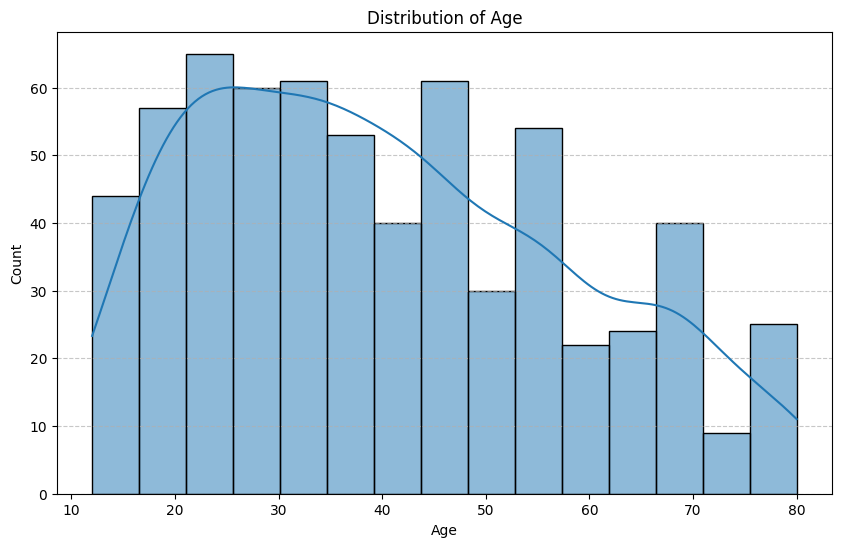

In [ ]:
# Create a histogram for the 'Age' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

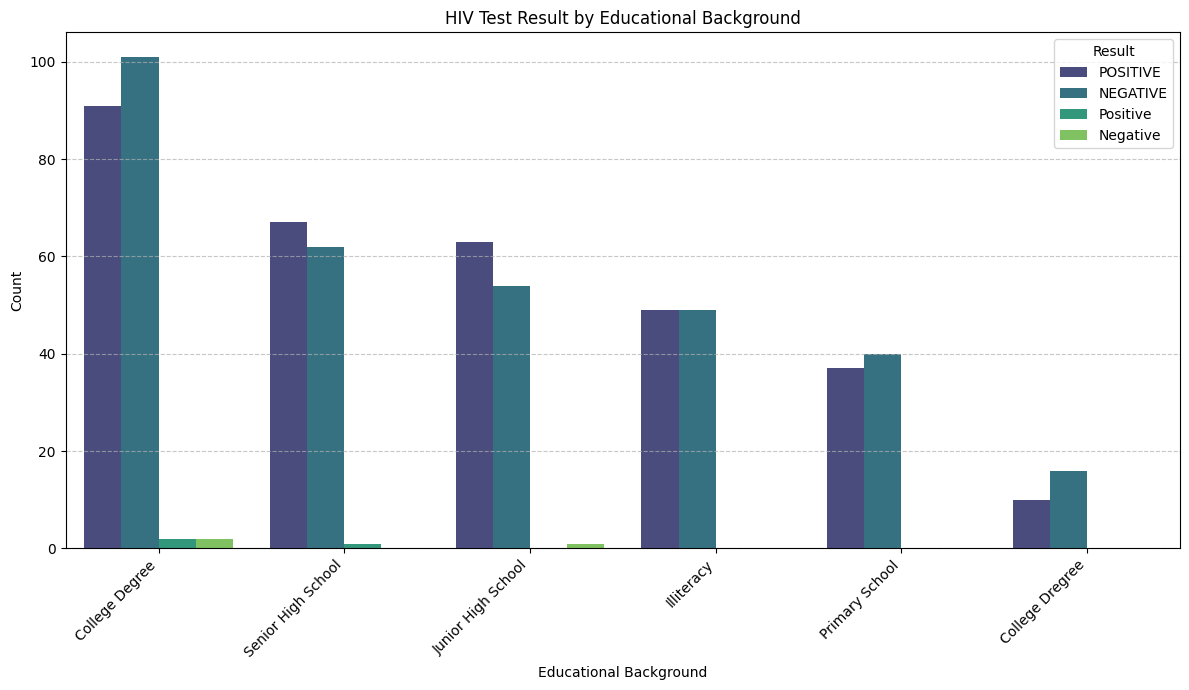

In [ ]:
# Create a countplot to show the relationship between 'Educational Background' and 'Result'
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Educational Background', hue='Result', palette='viridis')
plt.title('HIV Test Result by Educational Background')
plt.xlabel('Educational Background')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.legend(title='Result')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df

,Age,Marital Staus,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug- taking,Result
0,22,UNMARRIED,NO,College Degree,YES,NO,Bar,Heterosexual,YES,POSITIVE
1,20,UNMARRIED,NO,College Degree,NO,YES,Internet,Heterosexual,NO,NEGATIVE
2,23,Married,YES,College Degree,NO,YES,Internet,Bisexual,NO,NEGATIVE
3,24,Married,NO,College Degree,YES,YES,Park,Heterosexual,YES,POSITIVE
4,18,UNMARRIED,YES,Senior High School,YES,NO,Internet,Heterosexual,YES,POSITIVE
...,...,...,...,...,...,...,...,...,...,...
693,18,UNMARRIED,YES,Illiteracy,NO,NO,Internet,Heterosexual,NO,POSITIVE
694,46,MARRIED,NO,College Degree,NO,YES,Bar,Bisexual,NO,NEGATIVE
695,33,UNMARRIED,YES,Senior High School,YES,YES,Park,Homosexual,YES,NEGATIVE
696,24,MARRIED,NO,Junior High School,NO,NO,Public Bath,Heterosexual,YES,POSITIVE


In [ ]:
# Convert all entries in the 'Result' column to lowercase
df['Result'] = df['Result'].str.lower()

# Display unique values to confirm the change
print("Unique values in 'Result' column after standardization:")
display(df['Result'].unique())



Unique values in 'Result' column after standardization:


array(['positive', 'negative'], dtype=object)

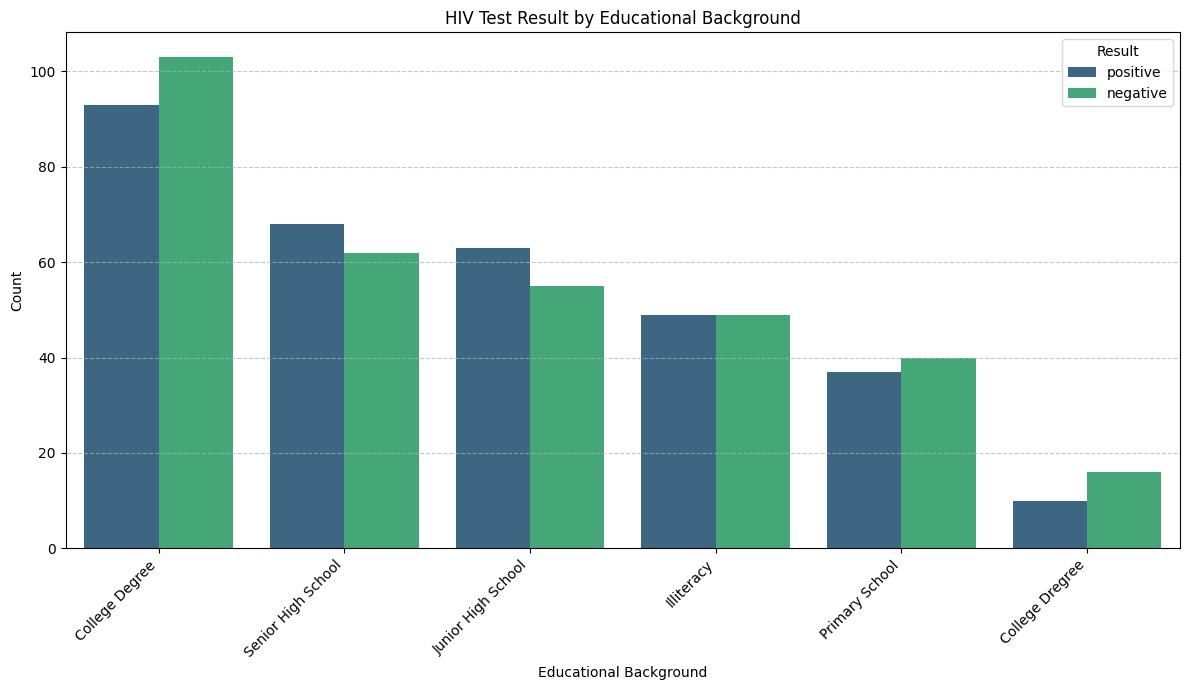

In [ ]:
# Create a countplot to show the relationship between 'Educational Background' and 'Result'
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Educational Background', hue='Result', palette='viridis')
plt.title('HIV Test Result by Educational Background')
plt.xlabel('Educational Background')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.legend(title='Result')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Get all columns with 'object' dtype (categorical columns)
categorical_cols = df.select_dtypes(include=['object']).columns

print("Unique values for each categorical column:\n")

# Iterate through each categorical column and print its unique values
for col in categorical_cols:
    # Skip the 'Result' column as it has already been processed
    if col == 'Result':
        continue
    print(f"Column: '{col}'")
    display(df[col].unique())
    print("---\n")

Unique values for each categorical column:

Column: 'Marital Staus'


array(['UNMARRIED', 'Married', 'MARRIED', 'Widowed', 'Divorced',
       'Cohabiting', 'DIvorced'], dtype=object)

---

Column: 'STD'


array(['NO', 'YES', 'No', 'Yes'], dtype=object)

---

Column: 'Educational Background'


...

---

Column: 'SEXUAL ORIENTATION'


array(['Heterosexual', 'Bisexual', 'Homosexual', 'Hetersexual',
       'BIsexual'], dtype=object)

---

Column: 'Drug- taking'


array(['YES', 'NO', 'No', 'Yes'], dtype=object)

---



In [ ]:
columns_lower = [
    'Marital Staus',
    'STD',
    'Educational Background',
    'HIV TEST IN PAST YEAR',
    'AIDS education',
    'Places of seeking sex partners',
    'SEXUAL ORIENTATION',
    'Drug- taking'
]

for col in columns_lower:
    if col in df.columns:
        # Convert to string type first to avoid errors with non-string entries,
        # then convert to lowercase.
        df[col] = df[col].astype(str).str.lower()

    else:
        print("No column found")

In [ ]:
df

,Age,Marital Staus,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug- taking,Result
0,22,unmarried,no,college degree,yes,no,bar,heterosexual,yes,positive
1,20,unmarried,no,college degree,no,yes,internet,heterosexual,no,negative
2,23,married,yes,college degree,no,yes,internet,bisexual,no,negative
3,24,married,no,college degree,yes,yes,park,heterosexual,yes,positive
4,18,unmarried,yes,senior high school,yes,no,internet,heterosexual,yes,positive
...,...,...,...,...,...,...,...,...,...,...
693,18,unmarried,yes,illiteracy,no,no,internet,heterosexual,no,positive
694,46,married,no,college degree,no,yes,bar,bisexual,no,negative
695,33,unmarried,yes,senior high school,yes,yes,park,homosexual,yes,negative
696,24,married,no,junior high school,no,no,public bath,heterosexual,yes,positive


In [ ]:
df.nunique()

,0
Age,65
Marital Staus,5
STD,2
Educational Background,6
HIV TEST IN PAST YEAR,2
AIDS education,2
Places of seeking sex partners,5
SEXUAL ORIENTATION,4
Drug- taking,2
Result,2


In [ ]:
df['Marital Staus'].unique()

array(['unmarried', 'married', 'widowed', 'divorced', 'cohabiting'],
      dtype=object)

In [ ]:
df['Educational Background'].unique()

array(['college degree', 'senior high school', 'junior high school',
       'illiteracy', 'primary school', 'college dregree'], dtype=object)

In [ ]:
df['Places of seeking sex partners'].unique()

array(['bar', 'internet', 'park', 'public bath', 'others'], dtype=object)

In [ ]:
df['SEXUAL ORIENTATION'].unique()

array(['heterosexual', 'bisexual', 'homosexual', 'hetersexual'],
      dtype=object)

/tmp/ipykernel_816/132586846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df['Age'], palette='viridis')


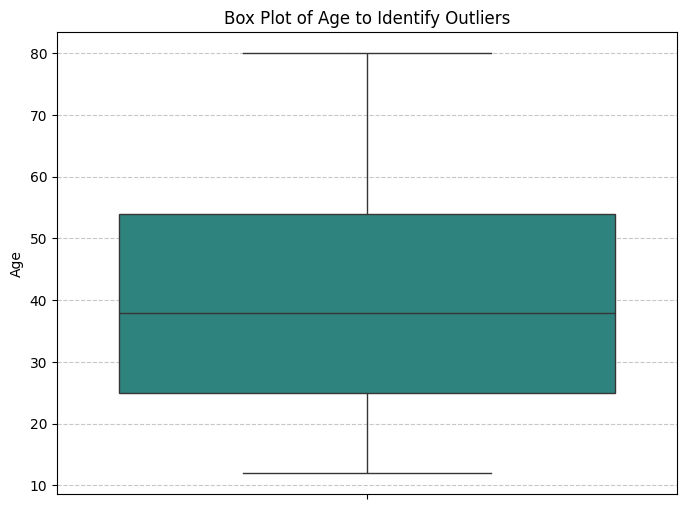

In [ ]:
#Visualizing outliers in the age column
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'], palette='viridis')
plt.title('Box Plot of Age to Identify Outliers')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

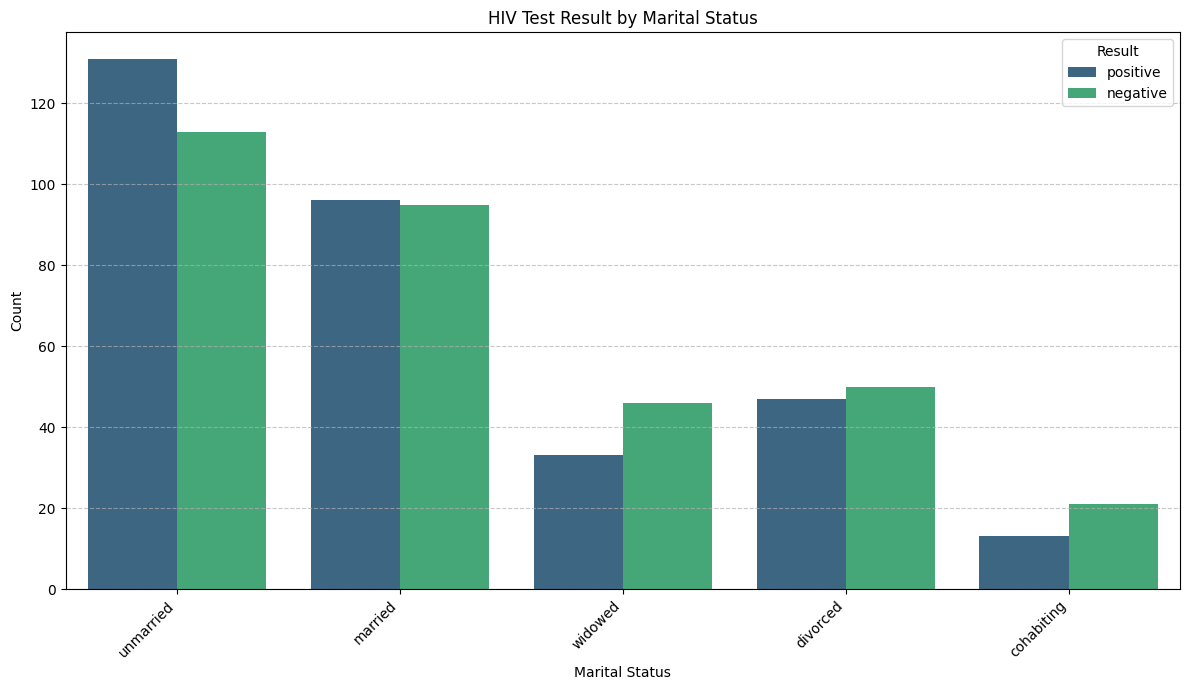

In [ ]:
# Create a countplot to show the relationship between 'Marital Staus' and 'Result'
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Marital Staus', hue='Result', palette='viridis')
plt.title('HIV Test Result by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.legend(title='Result')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Import necessary library for splitting data
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Result', axis=1) # All columns except 'Result'
y = df['Result'] # The 'Result' column is our target variable

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing, and 80% for training
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (516, 9)
Shape of X_test: (129, 9)
Shape of y_train: (516,)
Shape of y_test: (129,)


In [ ]:
# Identify categorical columns in X_train
categorical_X_train = X_train.select_dtypes(include=['object']).columns



# Apply one-hot encoding to the categorical columns in X_train
# 'drop_first=True' helps to prevent multicollinearity (though not strictly necessary for many models)
X_train_encoded = pd.get_dummies(X_train, columns=categorical_X_train, dtype=int, drop_first=True)

X_train_encoded.shape

display(X_train_encoded.head())

,Age,Marital Staus_divorced,Marital Staus_married,Marital Staus_unmarried,Marital Staus_widowed,STD_yes,Educational Background_college dregree,Educational Background_illiteracy,Educational Background_junior high school,Educational Background_primary school,...,HIV TEST IN PAST YEAR_yes,AIDS education_yes,Places of seeking sex partners_internet,Places of seeking sex partners_others,Places of seeking sex partners_park,Places of seeking sex partners_public bath,SEXUAL ORIENTATION_heterosexual,SEXUAL ORIENTATION_hetersexual,SEXUAL ORIENTATION_homosexual,Drug- taking_yes
568,25,0,0,1,0,1,1,0,0,0,...,0,1,0,0,1,0,0,0,0,1
29,19,0,0,1,0,1,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
274,25,0,1,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,0,1,0
629,22,0,0,1,0,1,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
487,23,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [ ]:
# Identify categorical columns in X_test (these should be the same as X_train's original categorical columns)
categorical_X_test = X_test.select_dtypes(include=['object']).columns



# Apply one-hot encoding to the categorical columns in X_test
X_test_encoded = pd.get_dummies(X_test, columns=categorical_X_test, dtype=int, drop_first=True)


X_test_encoded.shape
display(X_test_encoded.head())

,Age,Marital Staus_divorced,Marital Staus_married,Marital Staus_unmarried,Marital Staus_widowed,STD_yes,Educational Background_college dregree,Educational Background_illiteracy,Educational Background_junior high school,Educational Background_primary school,Educational Background_senior high school,HIV TEST IN PAST YEAR_yes,AIDS education_yes,Places of seeking sex partners_internet,Places of seeking sex partners_others,Places of seeking sex partners_park,Places of seeking sex partners_public bath,SEXUAL ORIENTATION_heterosexual,SEXUAL ORIENTATION_homosexual,Drug- taking_yes
685,20,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
645,53,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0
652,40,1,0,0,0,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0
291,57,0,0,0,1,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0
72,25,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0


In [ ]:
# Ensure X_test_encoded has the exact same columns as X_train_encoded
# This handles cases where X_test might be missing categories present in X_train
# or have extra categories not present in X_train.
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Identify the numerical column to be scaled (Age)
numerical_cols = ['Age']

# Fit the scaler on the training data's numerical column and transform it
X_train_encoded[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])

# Transform the testing data's numerical column using the *same fitted scaler*
X_test_encoded[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])



In [ ]:

display(X_train_encoded.head())



,Age,Marital Staus_divorced,Marital Staus_married,Marital Staus_unmarried,Marital Staus_widowed,STD_yes,Educational Background_college dregree,Educational Background_illiteracy,Educational Background_junior high school,Educational Background_primary school,...,HIV TEST IN PAST YEAR_yes,AIDS education_yes,Places of seeking sex partners_internet,Places of seeking sex partners_others,Places of seeking sex partners_park,Places of seeking sex partners_public bath,SEXUAL ORIENTATION_heterosexual,SEXUAL ORIENTATION_hetersexual,SEXUAL ORIENTATION_homosexual,Drug- taking_yes
568,-0.871068,0,0,1,0,1,1,0,0,0,...,0,1,0,0,1,0,0,0,0,1
29,-1.204462,0,0,1,0,1,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
274,-0.871068,0,1,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,0,1,0
629,-1.037765,0,0,1,0,1,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
487,-0.982199,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [ ]:

display(X_test_encoded.head())

,Age,Marital Staus_divorced,Marital Staus_married,Marital Staus_unmarried,Marital Staus_widowed,STD_yes,Educational Background_college dregree,Educational Background_illiteracy,Educational Background_junior high school,Educational Background_primary school,...,HIV TEST IN PAST YEAR_yes,AIDS education_yes,Places of seeking sex partners_internet,Places of seeking sex partners_others,Places of seeking sex partners_park,Places of seeking sex partners_public bath,SEXUAL ORIENTATION_heterosexual,SEXUAL ORIENTATION_hetersexual,SEXUAL ORIENTATION_homosexual,Drug- taking_yes
685,-1.148896,0,0,1,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
645,0.684772,1,0,0,0,1,0,0,0,1,...,1,0,0,0,0,1,0,0,0,0
652,-0.037582,1,0,0,0,1,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
291,0.907035,0,0,0,1,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
72,-0.871068,0,1,0,0,1,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0


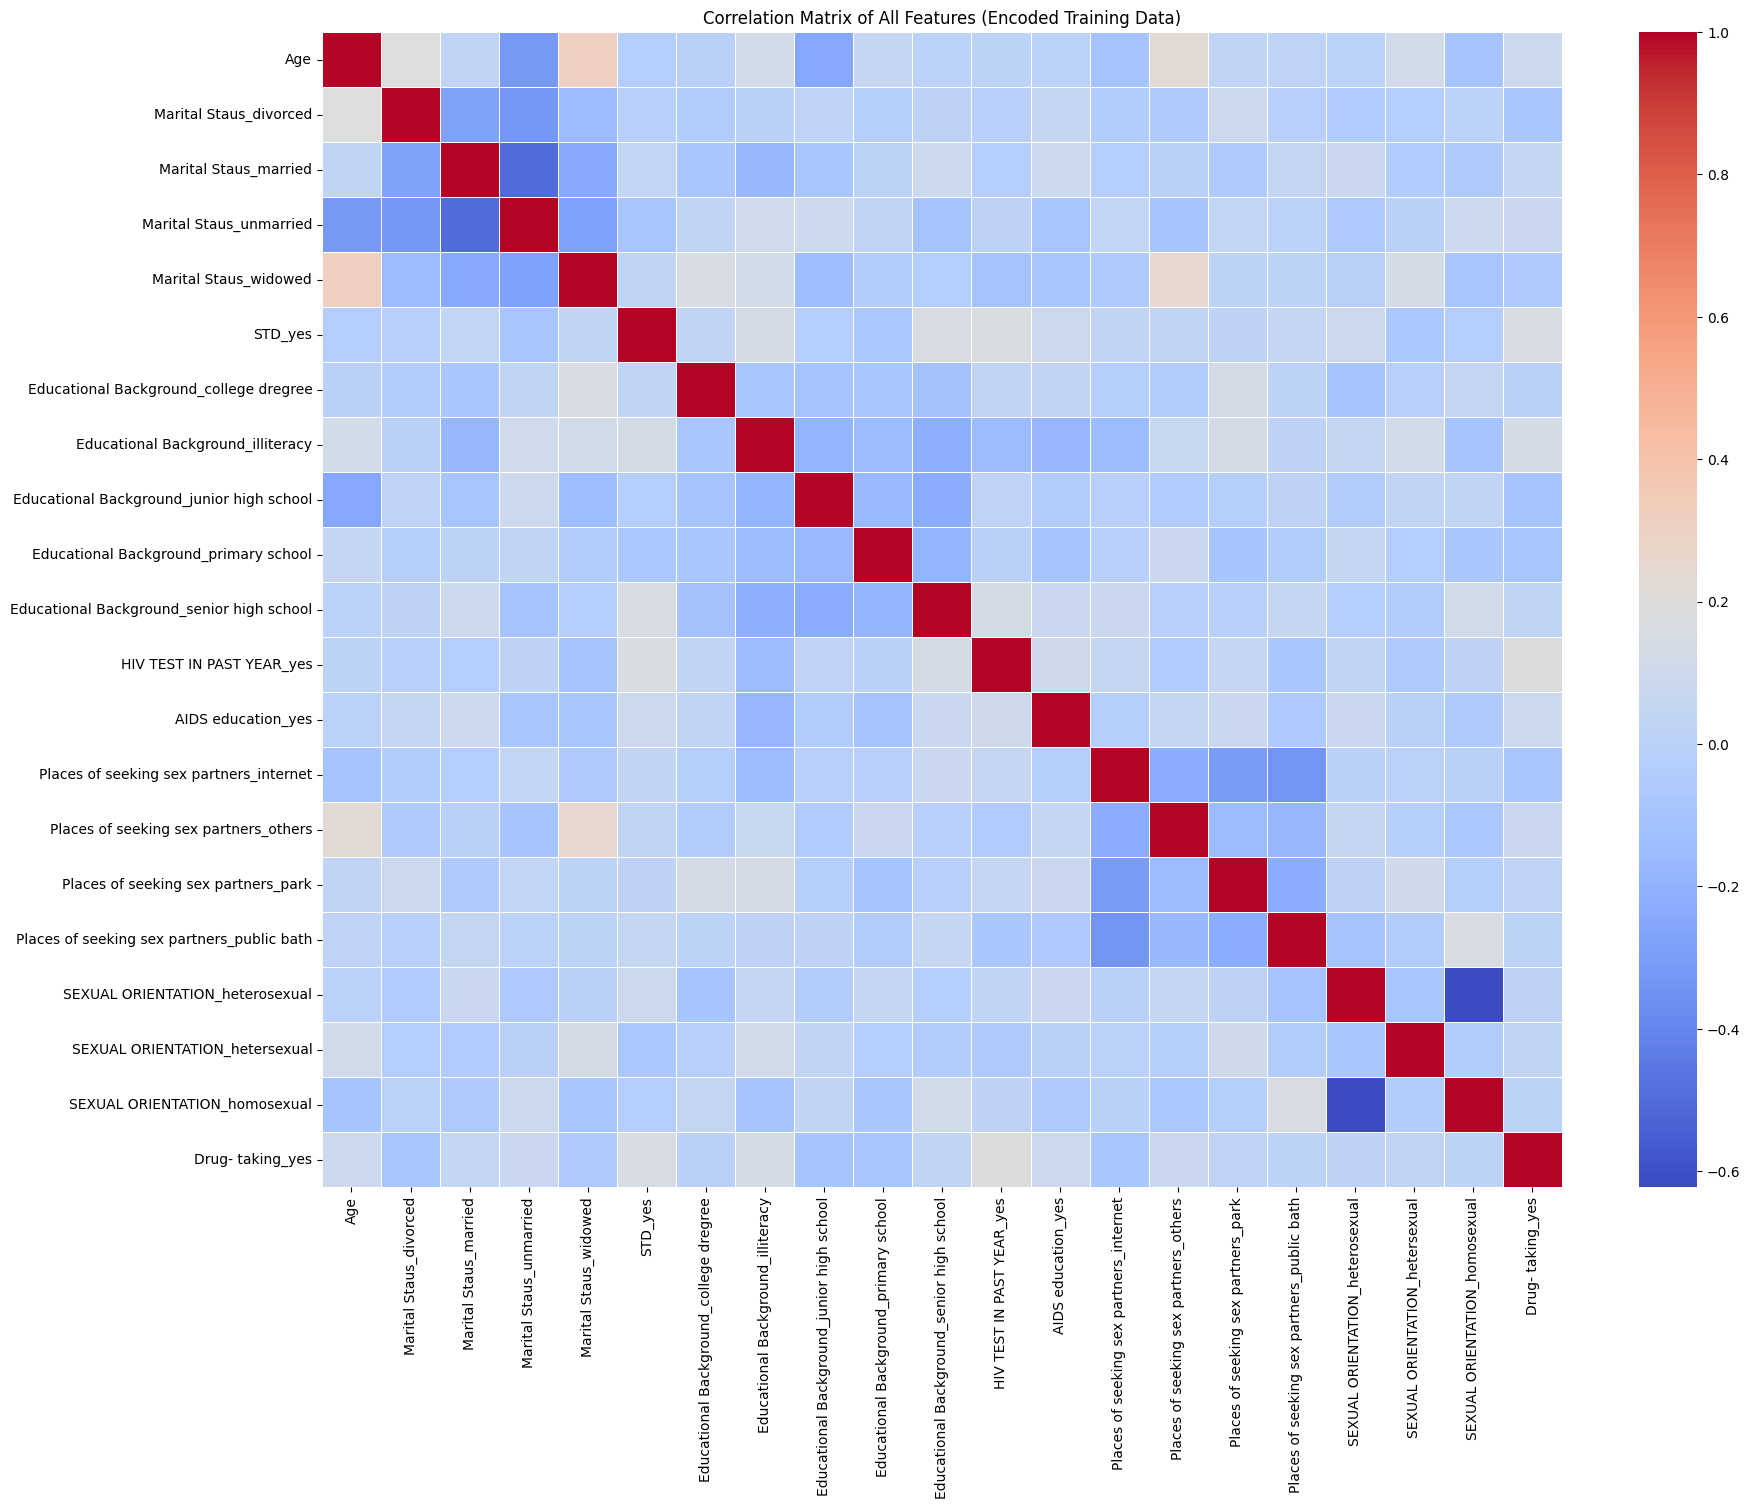

In [ ]:
# Calculate the correlation matrix for X_train_encoded
correlation_matrix = X_train_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 15))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features (Encoded Training Data)')
plt.show()

In [ ]:
# Import Logistic Regression model and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize the Logistic Regression model
# Set a random_state for reproducibility
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for smaller datasets and handles L1/L2 regularization

# Train the model using the encoded training data
model.fit(X_train_encoded, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the encoded test set
y_pred_reg = model.predict(X_test_encoded)

# Evaluate the model
print("\n--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_reg, pos_label='positive'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_reg, pos_label='positive'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_reg, pos_label='positive'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_reg))




--- Logistic Regression Model Evaluation ---
Accuracy: 0.7984
Precision: 0.8406
Recall: 0.7945
F1-Score: 0.8169

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.80      0.78        56
    positive       0.84      0.79      0.82        73

    accuracy                           0.80       129
   macro avg       0.80      0.80      0.80       129
weighted avg       0.80      0.80      0.80       129



In [ ]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
# Set a random_state for reproducibility and max_depth for simplicity
decision_tree_model = DecisionTreeClassifier(random_state=42, max_depth=5) # Limiting depth for simpler model

# Train the model
decision_tree_model.fit(X_train_encoded, y_train)

print("Decision Tree Classifier model trained successfully!")

Decision Tree Classifier model trained successfully!


In [ ]:
# Make predictions on the encoded test set
y_pred_dt = decision_tree_model.predict(X_test_encoded)

# Evaluate the model
print("\n--- Decision Tree Classifier Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, pos_label='positive'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt, pos_label='positive'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt, pos_label='positive'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))




--- Decision Tree Classifier Model Evaluation ---
Accuracy: 0.8062
Precision: 0.8750
Recall: 0.7671
F1-Score: 0.8175

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.86      0.79        56
    positive       0.88      0.77      0.82        73

    accuracy                           0.81       129
   macro avg       0.81      0.81      0.81       129
weighted avg       0.82      0.81      0.81       129



In [ ]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
# Set random_state for reproducibility and a reasonable number of estimators
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5) # Limiting depth for simplicity and faster training

# Train the model
rf_model.fit(X_train_encoded, y_train)

print("Random Forest Classifier model trained successfully!")

Random Forest Classifier model trained successfully!


In [ ]:
# Make predictions on the encoded test set
y_pred_rf = rf_model.predict(X_test_encoded)

# Evaluate the model
print("\n--- Random Forest Classifier Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label='positive'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label='positive'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, pos_label='positive'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))




--- Random Forest Classifier Model Evaluation ---
Accuracy: 0.8140
Precision: 0.8769
Recall: 0.7808
F1-Score: 0.8261

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.86      0.80        56
    positive       0.88      0.78      0.83        73

    accuracy                           0.81       129
   macro avg       0.81      0.82      0.81       129
weighted avg       0.82      0.81      0.81       129



In [ ]:
# Import Support Vector Classifier
from sklearn.svm import SVC

# Initialize the SVM model with a radial basis function (RBF) kernel
# Set random_state for reproducibility
svm_model = SVC(kernel='rbf', random_state=42)

# Train the model
svm_model.fit(X_train_encoded, y_train)

print("Support Vector Machine model trained successfully!")

Support Vector Machine model trained successfully!


In [ ]:
# Make predictions on the encoded test set
y_pred_svm = svm_model.predict(X_test_encoded)

# Evaluate the model
print("\n Support Vector Machine Model Evaluation ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, pos_label='positive'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm, pos_label='positive'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm, pos_label='positive'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))




 Support Vector Machine Model Evaluation 
Accuracy: 0.8295
Precision: 0.8696
Recall: 0.8219
F1-Score: 0.8451

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.84      0.81        56
    positive       0.87      0.82      0.85        73

    accuracy                           0.83       129
   macro avg       0.83      0.83      0.83       129
weighted avg       0.83      0.83      0.83       129



In [ ]:
# Import K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model
# We'll start with n_neighbors=5 as a common default, but this can be tuned.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_encoded, y_train)

print("K-Nearest Neighbors Classifier model trained successfully!")

K-Nearest Neighbors Classifier model trained successfully!


In [ ]:
# Make predictions on the encoded test set
y_pred_knn = knn_model.predict(X_test_encoded)

# Evaluate the model
print("\n--- K-Nearest Neighbors Classifier Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn, pos_label='positive'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn, pos_label='positive'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn, pos_label='positive'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))




--- K-Nearest Neighbors Classifier Model Evaluation ---
Accuracy: 0.7442
Precision: 0.8333
Recall: 0.6849
F1-Score: 0.7519

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.82      0.74        56
    positive       0.83      0.68      0.75        73

    accuracy                           0.74       129
   macro avg       0.75      0.75      0.74       129
weighted avg       0.76      0.74      0.74       129



In [ ]:
performance_data = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_reg),
        'Precision': precision_score(y_test, y_pred_reg, pos_label='positive'),
        'Recall': recall_score(y_test, y_pred_reg, pos_label='positive'),
        'F1-Score': f1_score(y_test, y_pred_reg, pos_label='positive')
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt, pos_label='positive'),
        'Recall': recall_score(y_test, y_pred_dt, pos_label='positive'),
        'F1-Score': f1_score(y_test, y_pred_dt, pos_label='positive')
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf, pos_label='positive'),
        'Recall': recall_score(y_test, y_pred_rf, pos_label='positive'),
        'F1-Score': f1_score(y_test, y_pred_rf, pos_label='positive')
    },
    'SVM': {
        'Accuracy': accuracy_score(y_test, y_pred_svm),
        'Precision': precision_score(y_test, y_pred_svm, pos_label='positive'),
        'Recall': recall_score(y_test, y_pred_svm, pos_label='positive'),
        'F1-Score': f1_score(y_test, y_pred_svm, pos_label='positive')
    },
    'KNN': {
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'Precision': precision_score(y_test, y_pred_knn, pos_label='positive'),
        'Recall': recall_score(y_test, y_pred_knn, pos_label='positive'),
        'F1-Score': f1_score(y_test, y_pred_knn, pos_label='positive')
    }
}

performance_df = pd.DataFrame(performance_data).T
display(performance_df)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.798450,0.840580,0.794521,0.816901
Decision Tree,0.806202,0.875000,0.767123,0.817518
Random Forest,0.813953,0.876923,0.780822,0.826087
SVM,0.829457,0.869565,0.821918,0.845070
KNN,0.744186,0.833333,0.684932,0.751880


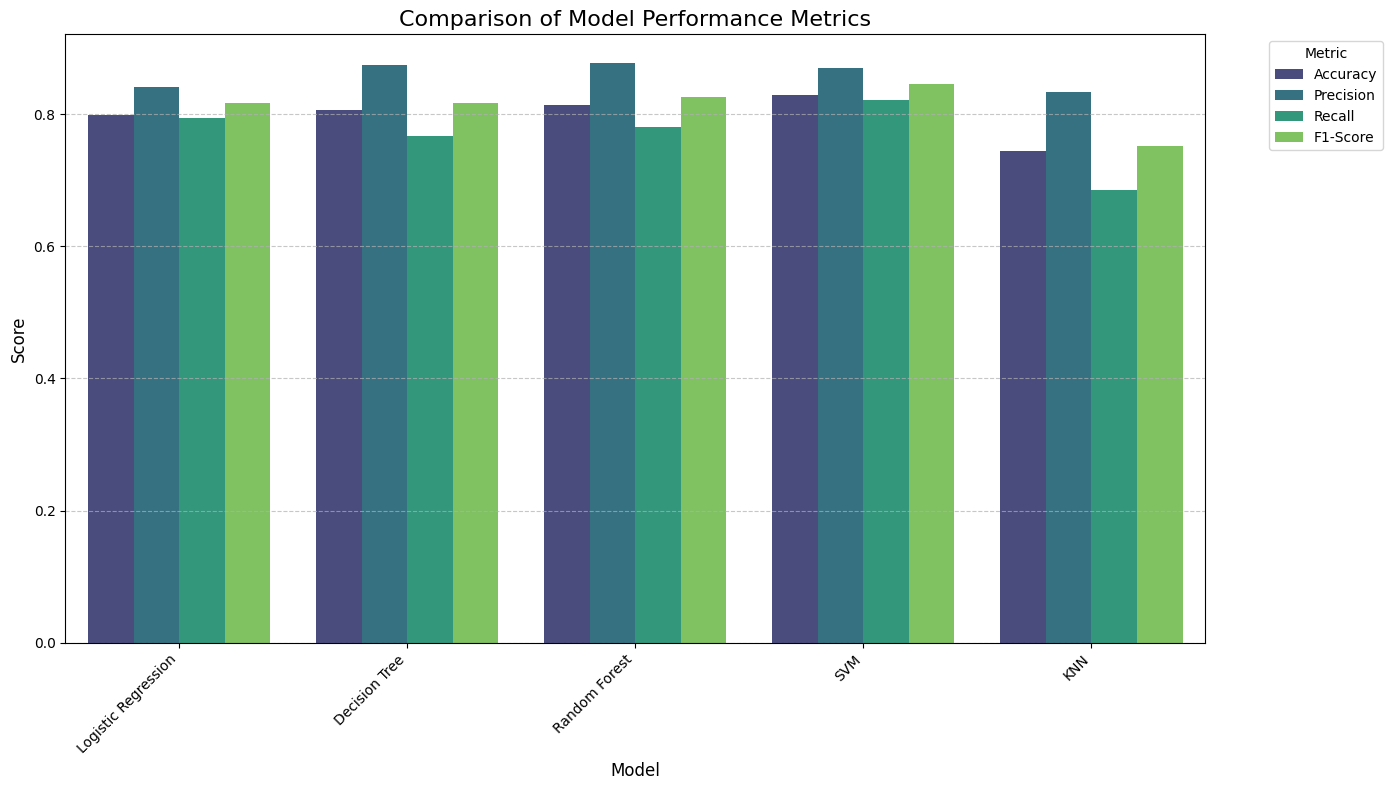

In [ ]:
# Melt the performance_df to long format for easier plotting
performance_df_melted = performance_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
performance_df_melted = performance_df_melted.rename(columns={'index': 'Model'})

plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=performance_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
best_model_f1 = performance_df['F1-Score'].idxmax()
max_f1_score = performance_df['F1-Score'].max()

print(f"The best model is '{best_model_f1}' with an F1-Score of {max_f1_score:.4f}.")

The best model is 'SVM' with an F1-Score of 0.8451.


In [ ]:
import pickle

# Define the filename for the best model
model_filename = 'best_svm_model.pkl'

# Save the best model (svm_model) to a file
with open(model_filename, 'wb') as file:
    pickle.dump(svm_model, file)

print(f"Best model saved successfully as '{model_filename}'")

Best model saved successfully as 'best_svm_model.pkl'


In [ ]:
from google.colab import files

# Download the saved model file
files.download(model_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Robust Validation & Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Define a simple parameter grid to search over
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

# Initialize SVC
svc = SVC(random_state=42)

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

# Fit the grid search to the training data
grid_search.fit(X_train_encoded, y_train)



GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10],
                         'gamma': ['scale', 'auto', 0.01, 0.1],
                         'kernel': ['rbf', 'linear']},
             scoring='f1_macro')

In [ ]:
# Get the best estimator and parameters
best_svm = grid_search.best_estimator_
print("Best Parameters Found:", grid_search.best_params_)
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

Best Parameters Found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.8656


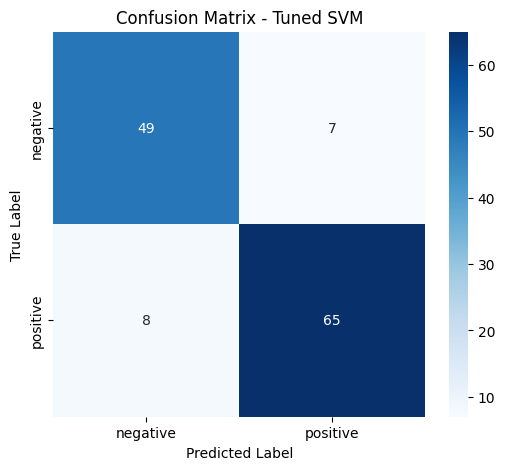

In [ ]:
# Predict on the test set with our best tuned model
#Error Analysis
y_pred_tuned = best_svm.predict(X_test_encoded)

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned, labels=['negative', 'positive'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix - Tuned SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()





In [ ]:
# 2. Extract and Inspect Misclassified Instances
# Reconstruct original test features for human readability
misclassified_mask = y_test != y_pred_tuned
misclassified_data = X_test[misclassified_mask].copy()
misclassified_data['True_Result'] = y_test[misclassified_mask]
misclassified_data['Predicted_Result'] = y_pred_tuned[misclassified_mask]

In [ ]:
print(f"Number of misclassified samples: {len(misclassified_data)} out of {len(y_test)}")
print("\nSample of misclassified records:")
display(misclassified_data.head())

Number of misclassified samples: 15 out of 129

Sample of misclassified records:


,Age,Marital Staus,STD,Educational Background,HIV TEST IN PAST YEAR,AIDS education,Places of seeking sex partners,SEXUAL ORIENTATION,Drug- taking,True_Result,Predicted_Result
564,25,divorced,no,illiteracy,no,yes,bar,homosexual,no,negative,positive
177,42,cohabiting,yes,senior high school,yes,no,internet,heterosexual,no,negative,positive
10,15,unmarried,no,illiteracy,no,no,others,homosexual,no,positive,negative
606,75,widowed,yes,illiteracy,no,no,park,heterosexual,no,positive,negative
55,23,married,yes,college degree,no,yes,internet,heterosexual,yes,positive,negative


In [ ]:
tuned_model_filename = 'tuned_best_svm_model.pkl'

# Save the tuned model
with open(tuned_model_filename, 'wb') as file:
    pickle.dump(best_svm, file)

print(f"Tuned model saved successfully as '{tuned_model_filename}'")

Tuned model saved successfully as 'tuned_best_svm_model.pkl'


In [ ]:
# Calculate final test metrics for the tuned model
#Performance Comparison (Before vs. After Tuning)
from sklearn.metrics import classification_report

print("Original SVM Test Performance")
print(classification_report(y_test, y_pred_svm))

print("Tuned SVM Test Performance")
print(classification_report(y_test, y_pred_tuned))

Original SVM Test Performance
              precision    recall  f1-score   support

    negative       0.78      0.84      0.81        56
    positive       0.87      0.82      0.85        73

    accuracy                           0.83       129
   macro avg       0.83      0.83      0.83       129
weighted avg       0.83      0.83      0.83       129

Tuned SVM Test Performance
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87        56
    positive       0.90      0.89      0.90        73

    accuracy                           0.88       129
   macro avg       0.88      0.88      0.88       129
weighted avg       0.88      0.88      0.88       129



In [ ]:
# Load the saved tuned model from disk
with open('tuned_best_svm_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Run a test prediction to verify
test_prediction = loaded_model.predict(X_test_encoded.head(5))
print("Verifying loaded model predictions on the first 5 test rows:")
print("Predictions:", test_prediction)
print("Actual labels:", y_test.head(5).tolist())

Verifying loaded model predictions on the first 5 test rows:
Predictions: ['positive' 'positive' 'positive' 'positive' 'negative']
Actual labels: ['positive', 'positive', 'positive', 'positive', 'negative']


In [ ]:
from google.colab import files

# Download the tuned best model file to your computer
files.download('tuned_best_svm_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>